# (0.) Load Dataset (!)

In [ ]:
diabetes <- read.csv("diabetes.csv")
# 0 = No Diabetes
# 1 = Diabetes

# Exploring dataset

In [ ]:
names(diabetes)

[1] "Pregnancies"              "Glucose"                 
[3] "BloodPressure"            "SkinThickness"           
[5] "Insulin"                  "BMI"                     
[7] "DiabetesPedigreeFunction" "Age"                     
[9] "Outcome"

In [ ]:
# Number of '0' values
sum(diabetes$Pregnancies == 0)
sum(diabetes$Glucose == 0)
sum(diabetes$BloodPressure == 0)
sum(diabetes$SkinThickness == 0)
sum(diabetes$Insulin == 0)
sum(diabetes$BMI == 0)
cat("\n")
sum(diabetes$DiabetesPedigreeFunction == 0)
sum(diabetes$Age == 0)
  # Possbily points to missing values encoded as 0's? (!)

[1] 111

[1] 5

[1] 35

[1] 227

[1] 374

[1] 11

[1] 0

[1] 0

In [ ]:
  # Outcome : response variable
  # All other columns : predictors
logmodel_original <- glm(Outcome ~ ., data = diabetes, family = binomial)
summary(logmodel_original)


Call:
glm(formula = Outcome ~ ., family = binomial, data = diabetes)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -8.4046964  0.7166359 -11.728  < 2e-16 ***
Pregnancies               0.1231823  0.0320776   3.840 0.000123 ***
Glucose                   0.0351637  0.0037087   9.481  < 2e-16 ***
BloodPressure            -0.0132955  0.0052336  -2.540 0.011072 *  
SkinThickness             0.0006190  0.0068994   0.090 0.928515    
Insulin                  -0.0011917  0.0009012  -1.322 0.186065    
BMI                       0.0897010  0.0150876   5.945 2.76e-09 ***
DiabetesPedigreeFunction  0.9451797  0.2991475   3.160 0.001580 ** 
Age                       0.0148690  0.0093348   1.593 0.111192    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 993.48  on 767  degrees of freedom
Residual deviance: 723.45  on 759  degrees of freedom
A

# Boxplots

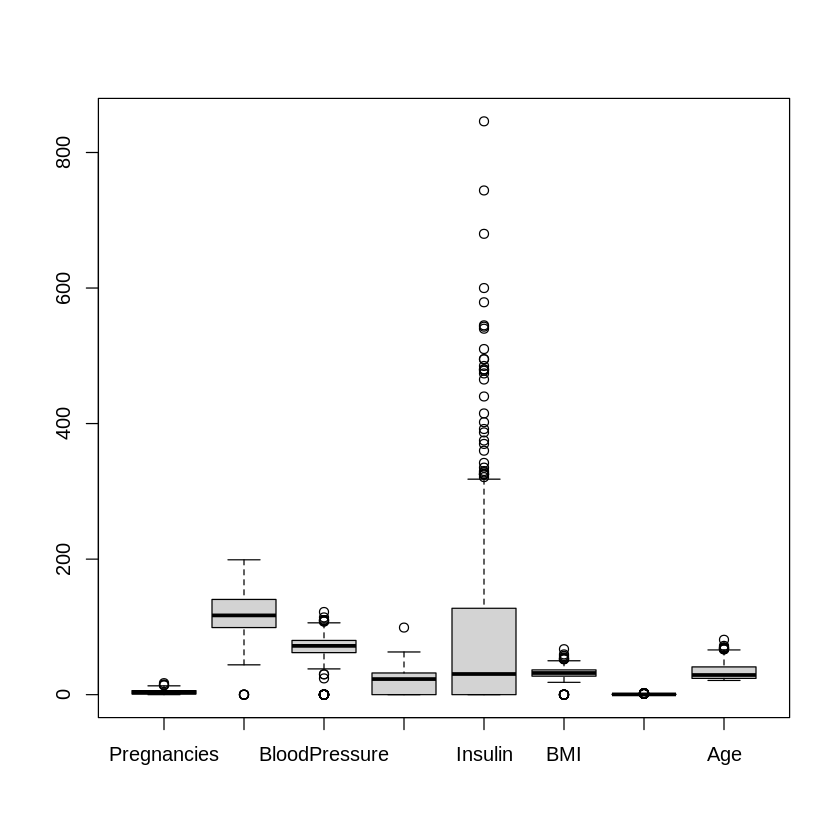

In [ ]:
boxplot(diabetes[,1:8]) # All Variables

In [ ]:
# Next, Individually By Outcome
#boxplot(Glucose ~ Outcome, data = diabetes, main = "Glucose by Outcome") # Glucose
#boxplot(BMI ~ Outcome, data = diabetes, main = "BMI by Outcome") # BMI
#boxplot(Insulin ~ Outcome, data = diabetes, main = "Insulin by Outcome") # Insulin
#boxplot(BloodPressure ~ Outcome, data = diabetes, main = "Bloodpressure by Outcome") # Blood Pressure

    Glucose

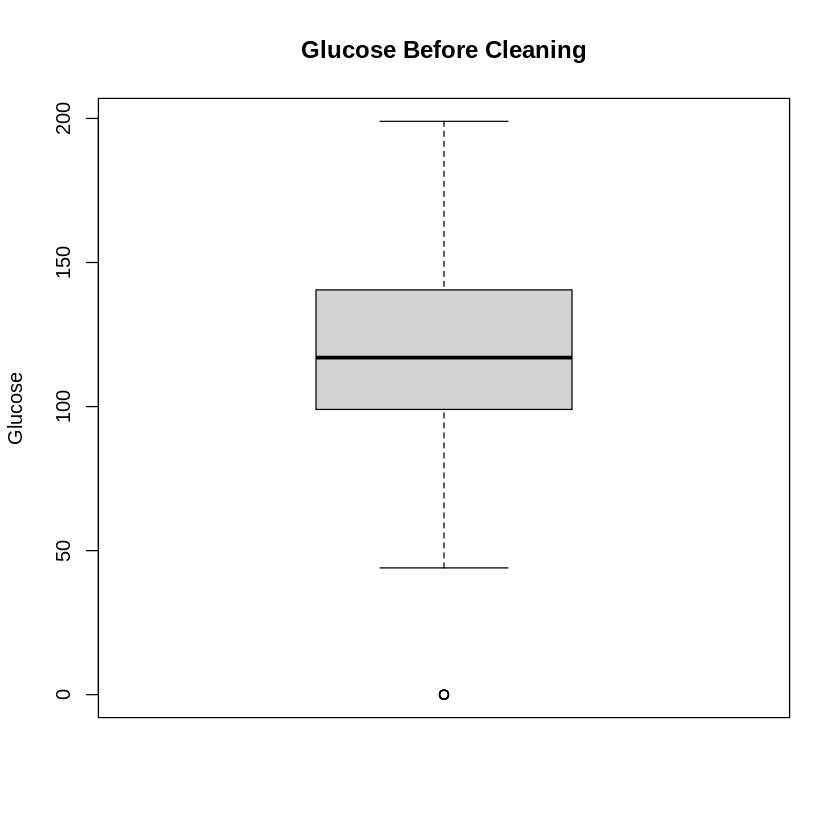

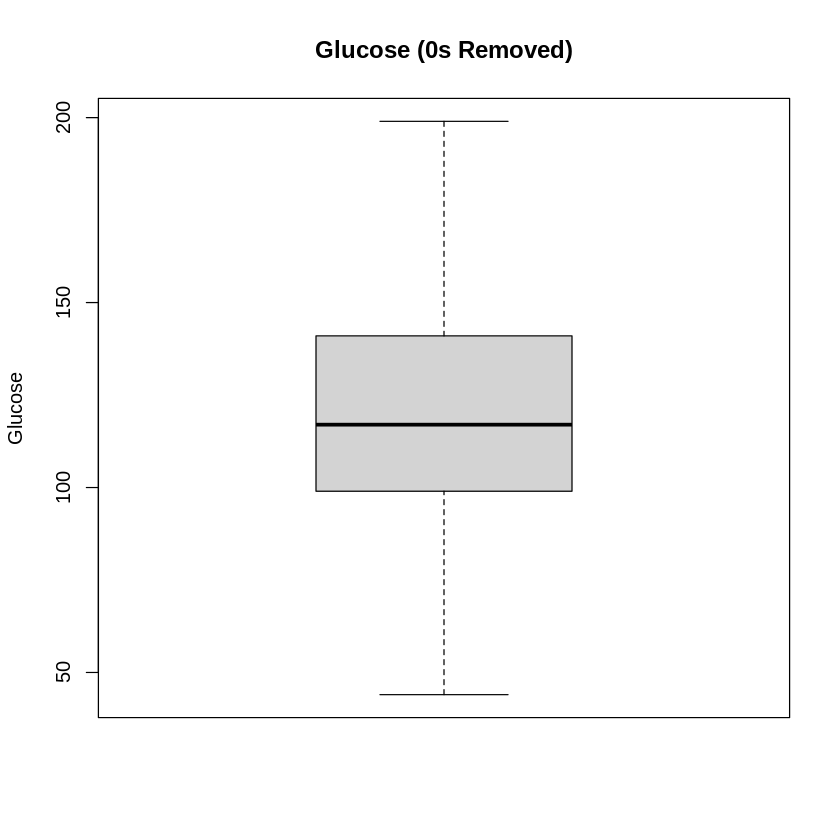

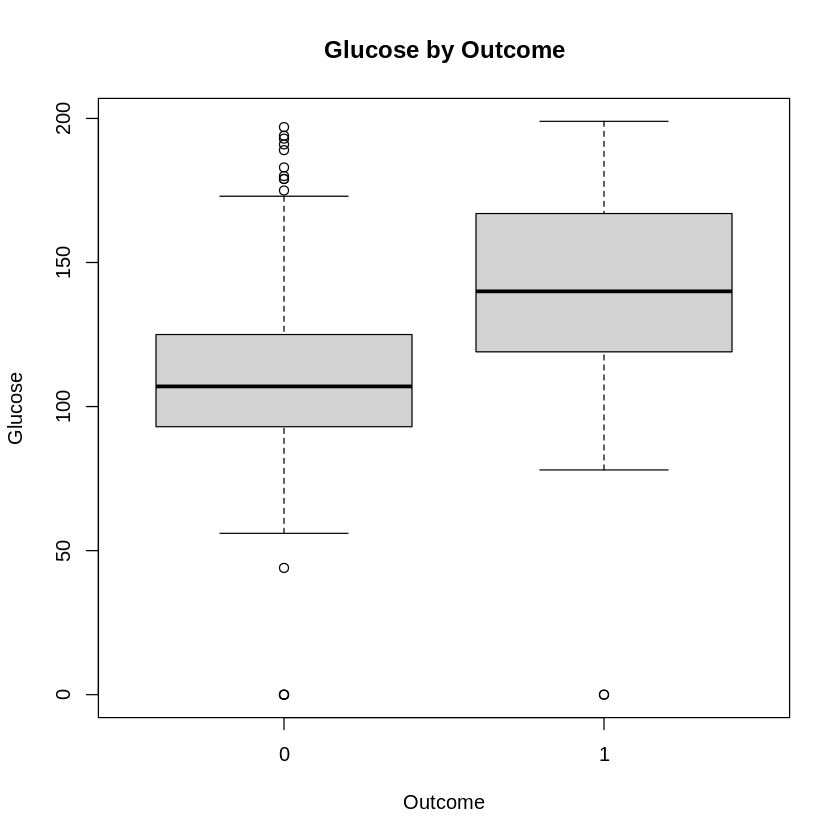

In [ ]:
boxplot(diabetes$Glucose, main = "Glucose Before Cleaning", ylab = "Glucose") # Inital boxplot

glucose_no0 <- diabetes$Glucose[diabetes$Glucose != 0] # Remove 0's for Visualization
boxplot(glucose_no0, main = "Glucose (0s Removed)", ylab = "Glucose")

boxplot(Glucose ~ Outcome, data = diabetes, main = "Glucose by Outcome", xlab = "Outcome", ylab = "Glucose") # By Outcome

    BMI

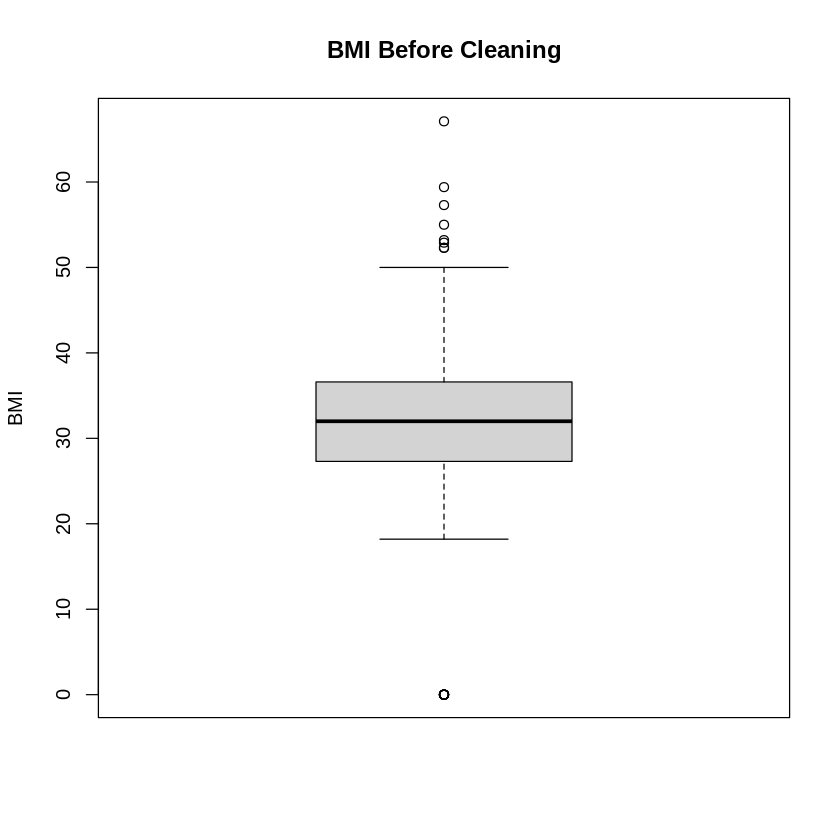

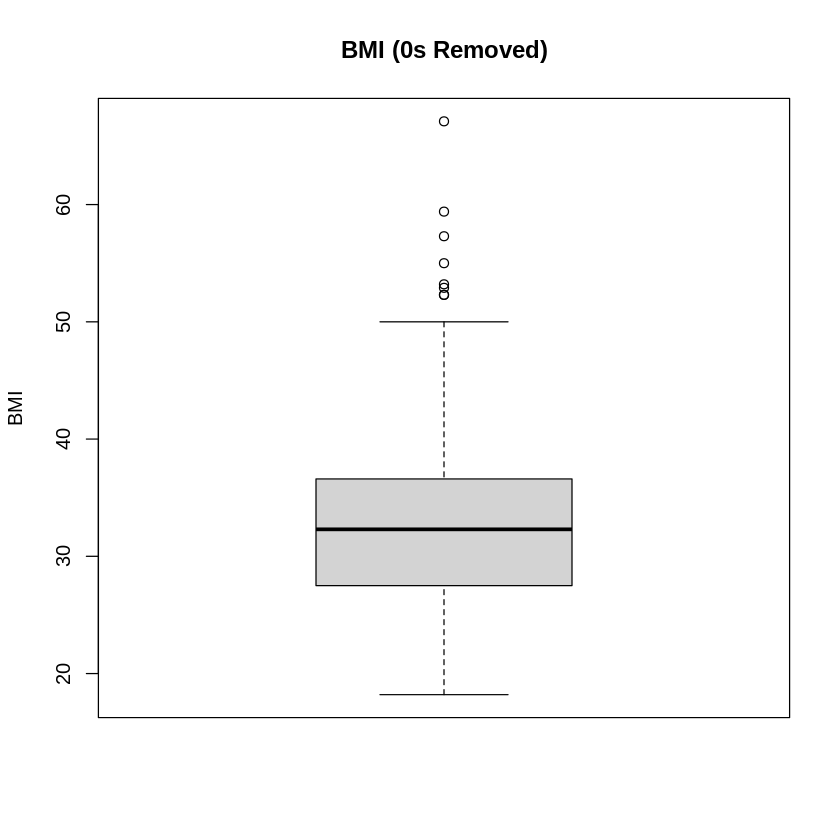

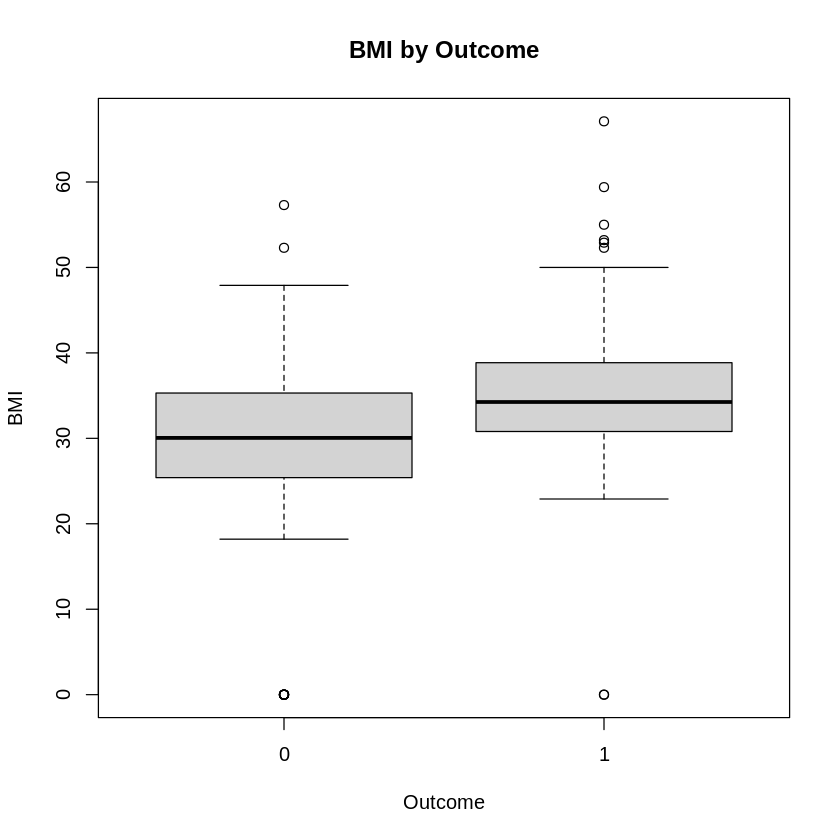

In [ ]:
boxplot(diabetes$BMI, main = "BMI Before Cleaning", ylab = "BMI") # Inital boxplot

BMI_no0 <- diabetes$BMI[diabetes$BMI != 0] # Remove 0's for Visualization
boxplot(BMI_no0, main = "BMI (0s Removed)", ylab = "BMI")

boxplot(BMI ~ Outcome, data = diabetes, main = "BMI by Outcome", xlab = "Outcome", ylab = "BMI") # By Outcome

    Insulin

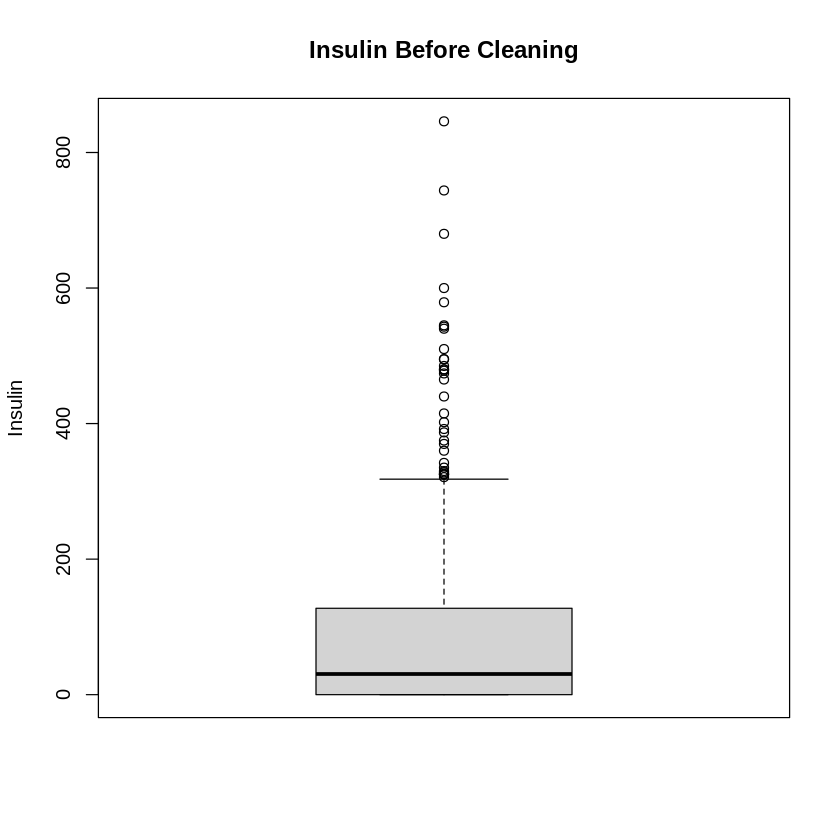

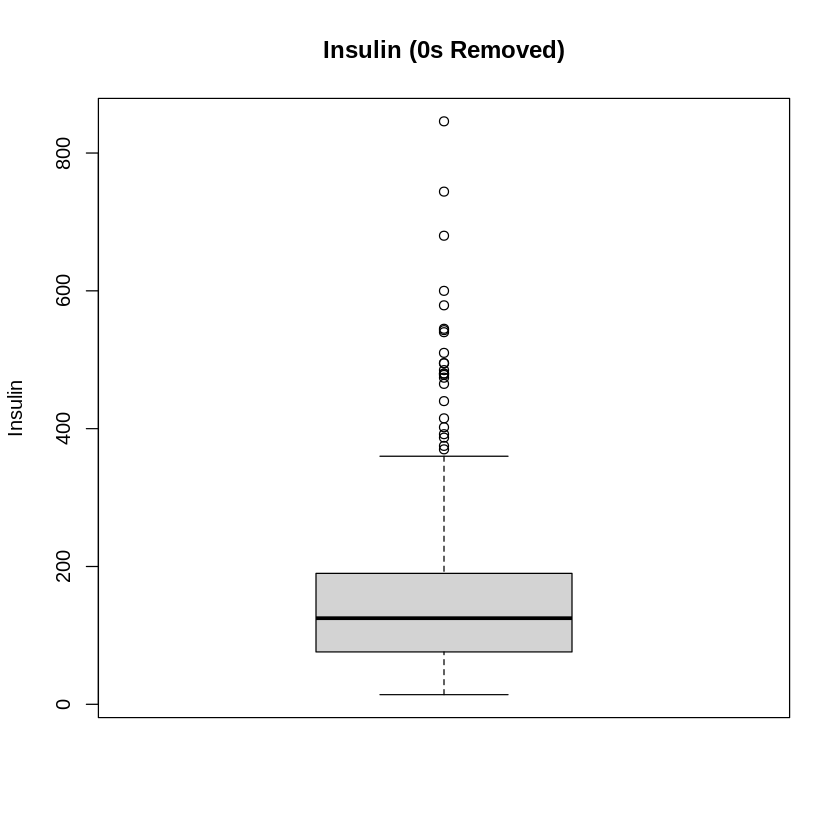

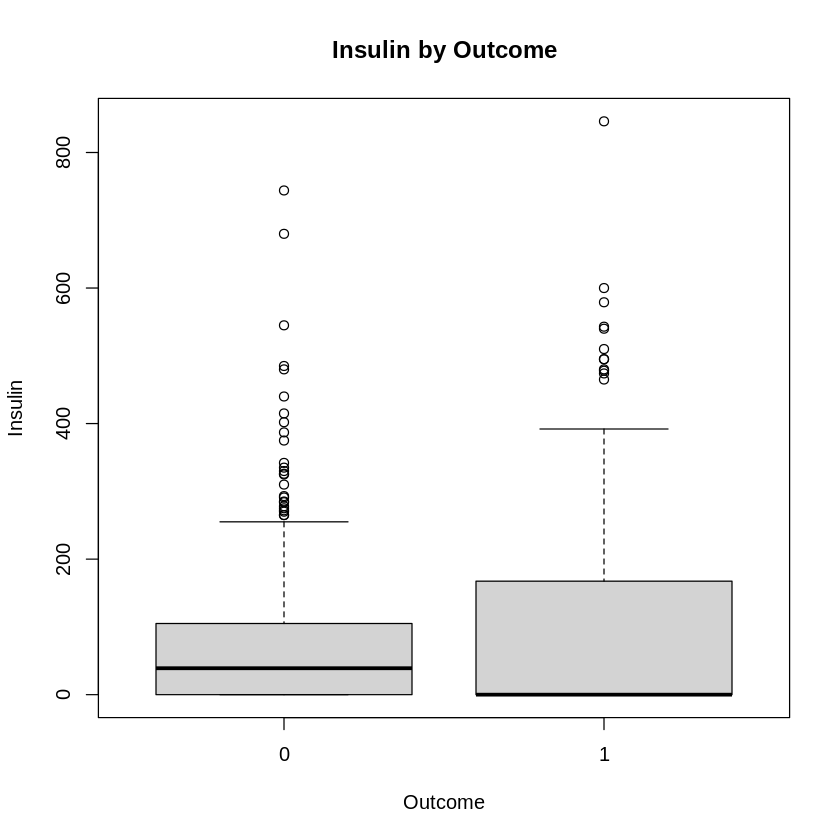

In [ ]:
boxplot(diabetes$Insulin, main = "Insulin Before Cleaning", ylab = "Insulin") # Initial Boxplot for Insulin

# Remove 0's for Visualization
insulin_no0 <- diabetes$Insulin[diabetes$Insulin != 0]
boxplot(insulin_no0, main = "Insulin (0s Removed)", ylab = "Insulin")

# Insulin by Outcome
boxplot(Insulin ~ Outcome, data = diabetes, main = "Insulin by Outcome", xlab = "Outcome", ylab = "Insulin")

    Blood Pressure

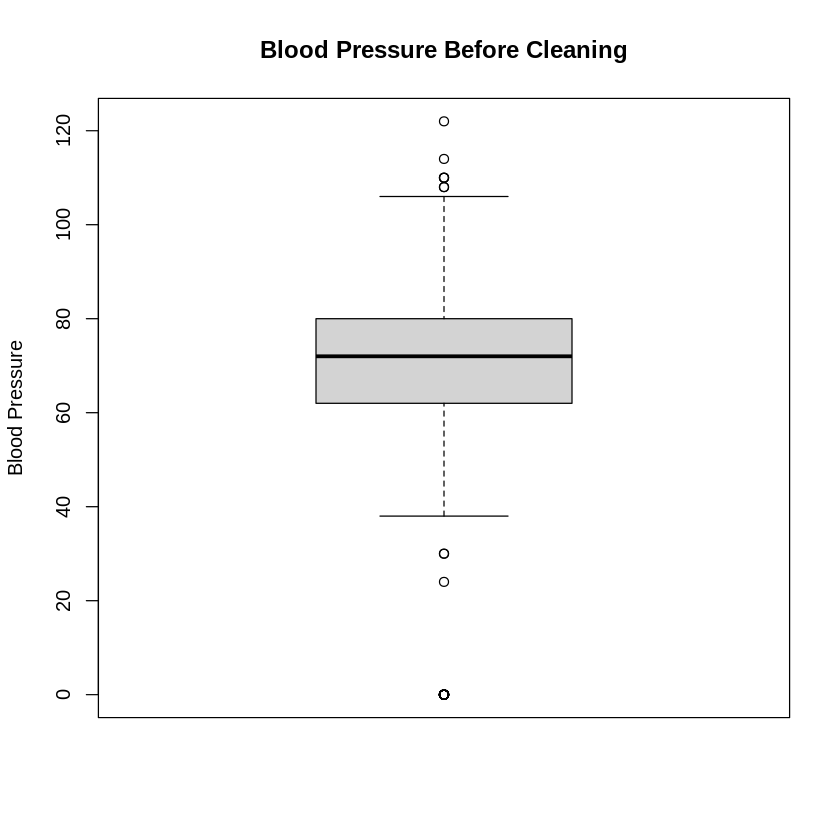

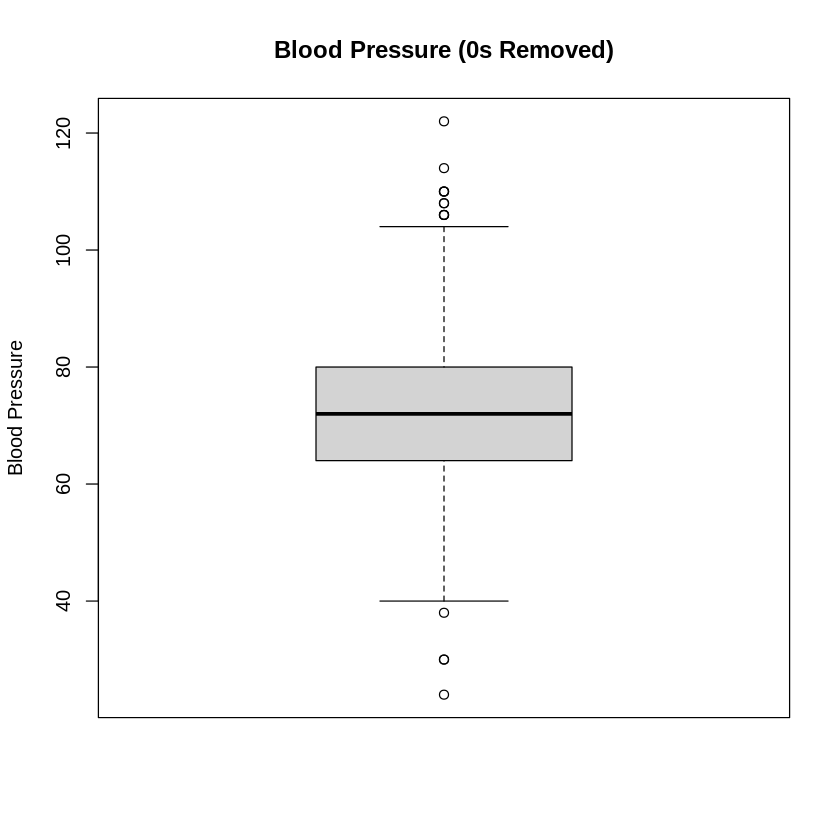

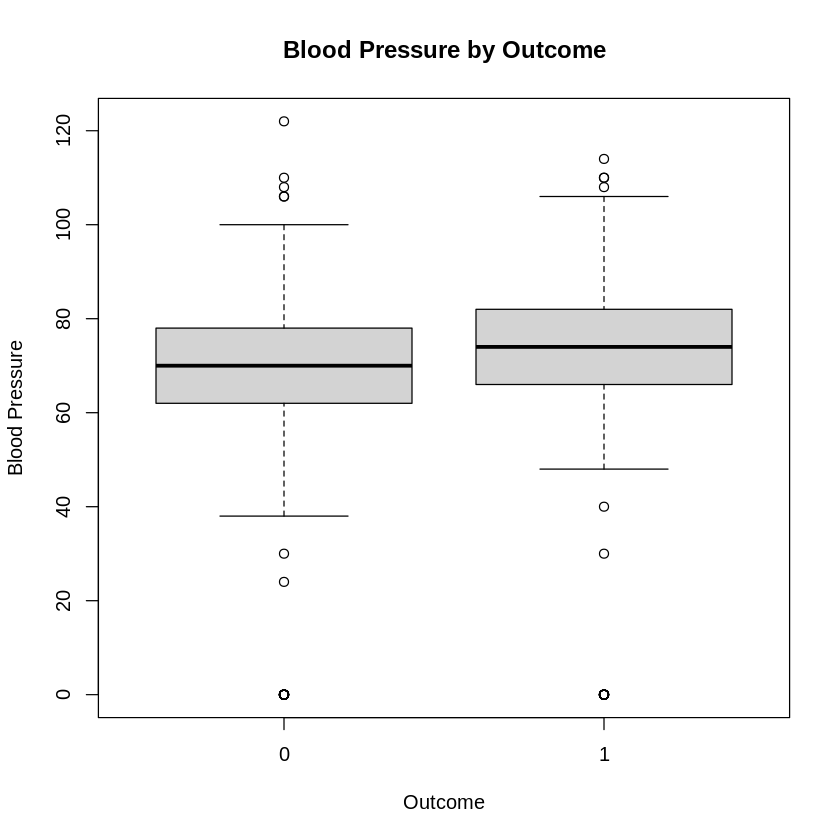

In [ ]:
boxplot(diabetes$BloodPressure, main = "Blood Pressure Before Cleaning", ylab = "Blood Pressure") # Inital boxplot

BP_no0 <- diabetes$BloodPressure[diabetes$BloodPressure != 0] # Remove 0's for Visualization
boxplot(BP_no0, main = "Blood Pressure (0s Removed)", ylab = "Blood Pressure")

boxplot(BloodPressure ~ Outcome, data = diabetes, main = "Blood Pressure by Outcome", xlab = "Outcome", ylab = "Blood Pressure") # By Outcome

    Skin Thickness

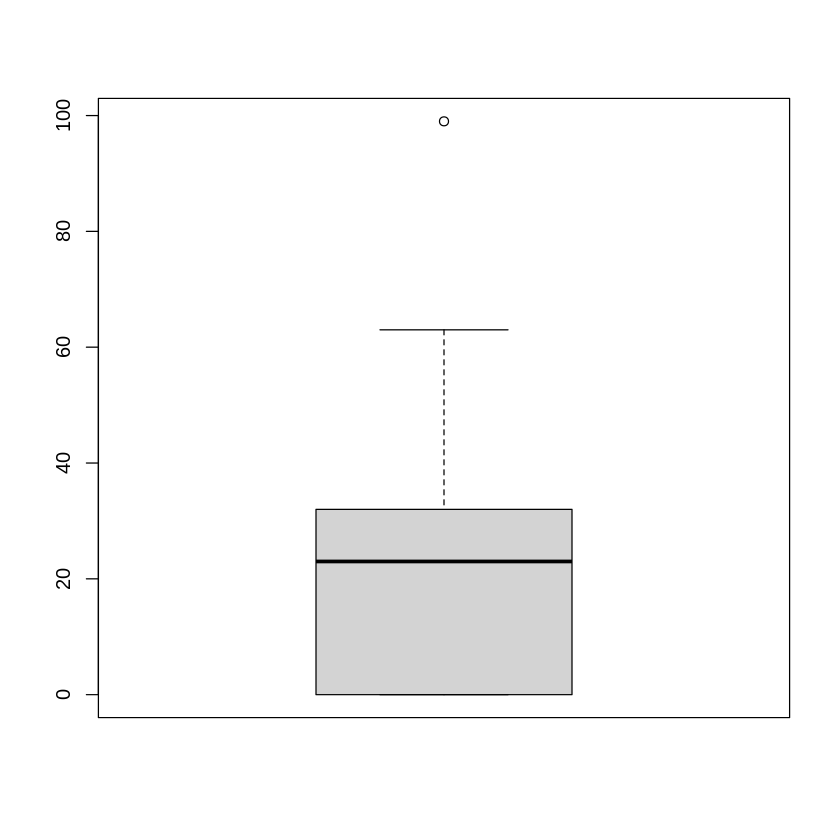

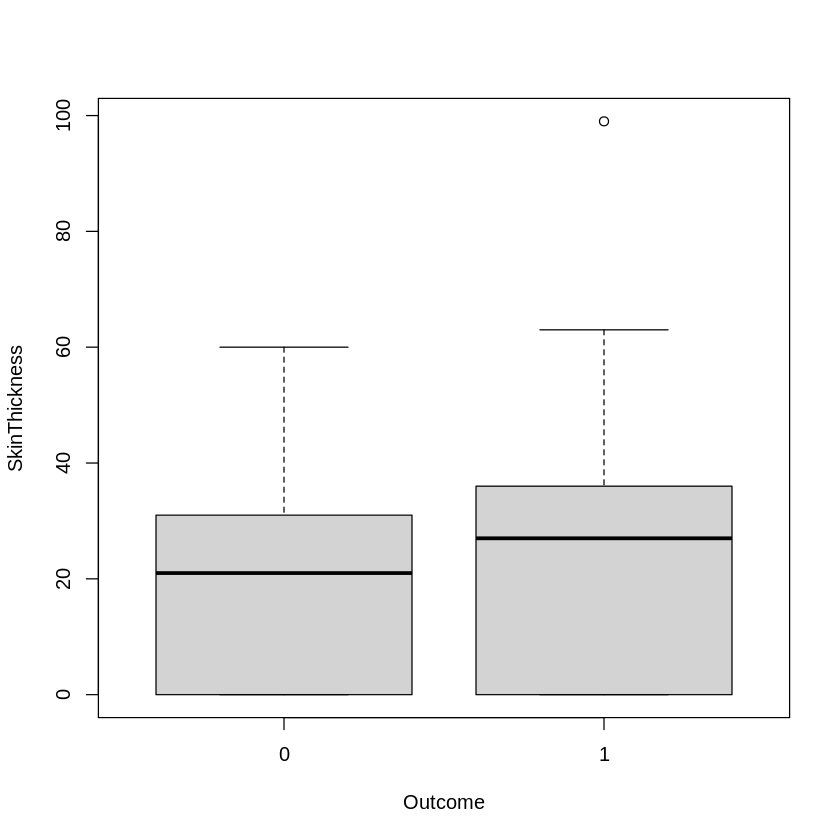

In [ ]:
boxplot(diabetes$SkinThickness)
boxplot(SkinThickness ~ Outcome, data = diabetes) # By Outcome

# (1.) Training-Testing Split (80:20) (!)

In [ ]:
set.seed(123) # Set Seed
# Train on 'diabetes' (want same results for class & global)
train_idx <- sample(1:nrow(diabetes), size = 0.8 * nrow(diabetes))

# Make copies of dataset after Split
  # Global
train_global <- diabetes[train_idx, ]
test_global <- diabetes[-train_idx, ]
  # Class
train_class <- diabetes[train_idx, ]
test_class <- diabetes[-train_idx, ]

# (2.) Calculate Means & Replace 0's (!)

    Global Mean

In [ ]:
cols <- c("Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI") # Get 0-value columns
global_means <- sapply(cols, function(col) {mean(train_global[[col]][train_global[[col]] != 0])}) # Calculate means on TRAIN ONLY

for(col in cols){train_global[[col]][train_global[[col]] == 0] <- global_means[col]} # Replace 0's in TRAIN
for(col in cols){test_global[[col]][test_global[[col]] == 0] <- global_means[col]} # Replace 0's in TEST

    Class Mean

In [ ]:
# TRAIN
  # Compute/Impute
# Insulin
mean_insulin_0 <- mean(train_class$Insulin[train_class$Outcome == 0 & train_class$Insulin != 0]) # When Outcome = 0 (Compute)
train_class$Insulin[train_class$Outcome == 0 & train_class$Insulin == 0] <- mean_insulin_0 # (Impute)
mean_insulin_1 <- mean(train_class$Insulin[train_class$Outcome == 1 & train_class$Insulin != 0]) # When Outcome = 1
train_class$Insulin[train_class$Outcome == 1 & train_class$Insulin == 0] <- mean_insulin_1

# Blood Pressure
mean_bp_0 <- mean(train_class$BloodPressure[train_class$Outcome == 0 & train_class$BloodPressure != 0])
train_class$BloodPressure[train_class$Outcome == 0 & train_class$BloodPressure == 0] <- mean_bp_0
mean_bp_1 <- mean(train_class$BloodPressure[train_class$Outcome == 1 & train_class$BloodPressure != 0])
train_class$BloodPressure[train_class$Outcome == 1 & train_class$BloodPressure == 0] <- mean_bp_1

# BMI
mean_bmi_0 <- mean(train_class$BMI[train_class$Outcome == 0 & train_class$BMI != 0])
train_class$BMI[train_class$Outcome == 0 & train_class$BMI == 0] <- mean_bmi_0
mean_bmi_1 <- mean(train_class$BMI[train_class$Outcome == 1 & train_class$BMI != 0])
train_class$BMI[train_class$Outcome == 1 & train_class$BMI == 0] <- mean_bmi_1

# Glucose
mean_glucose_0 <- mean(train_class$Glucose[train_class$Outcome == 0 & train_class$Glucose != 0])
train_class$Glucose[train_class$Outcome == 0 & train_class$Glucose == 0] <- mean_glucose_0
mean_glucose_1 <- mean(train_class$Glucose[train_class$Outcome == 1 & train_class$Glucose != 0])
train_class$Glucose[train_class$Outcome == 1 & train_class$Glucose == 0] <- mean_glucose_1

# Skin Thickness
mean_skin_0 <- mean(train_class$SkinThickness[train_class$Outcome == 0 & train_class$SkinThickness != 0])
train_class$SkinThickness[train_class$Outcome == 0 & train_class$SkinThickness == 0] <- mean_skin_0
mean_skin_1 <- mean(train_class$SkinThickness[train_class$Outcome == 1 & train_class$SkinThickness != 0])
train_class$SkinThickness[train_class$Outcome == 1 & train_class$SkinThickness == 0] <- mean_skin_1

In [ ]:
# TEST
  # Impute
test_class$Insulin[test_class$Outcome == 0 & test_class$Insulin == 0] <- mean_insulin_0
test_class$Insulin[test_class$Outcome == 1 & test_class$Insulin == 0 ] <- mean_insulin_1

test_class$BloodPressure[test_class$Outcome == 0 & test_class$BloodPressure == 0] <- mean_bp_0
test_class$BloodPressure[test_class$Outcome == 1 & test_class$BloodPressure == 0 ] <- mean_bp_1

test_class$BMI[test_class$Outcome == 0 & test_class$BMI == 0] <- mean_bmi_0
test_class$BMI[test_class$Outcome == 1 & test_class$BMI == 0 ] <- mean_bmi_1

test_class$Glucose[test_class$Outcome == 0 & test_class$Glucose == 0] <- mean_glucose_0
test_class$Glucose[test_class$Outcome == 1 & test_class$Glucose == 0 ] <- mean_glucose_1

test_class$SkinThickness[test_class$Outcome == 0 & test_class$SkinThickness == 0] <- mean_skin_0
test_class$SkinThickness[test_class$Outcome == 1 & test_class$SkinThickness == 0 ] <- mean_skin_1

# Mean Results

In [ ]:
mean_insulin_0
mean_insulin_1
cat("\n")
mean_bp_0
mean_bp_1
cat("\n")
mean_bmi_0
mean_bmi_1
cat("\n")
mean_glucose_0
mean_glucose_1
cat("\n")
mean_skin_0
mean_skin_1

[1] 129.3821

[1] 206.2818

[1] 70.53665

[1] 74.58333

[1] 30.76122

[1] 35.3785

[1] 110.9848

[1] 143.2103

[1] 27.27083

[1] 32.73333

# (3.) Logistic Regressions (!)

In [ ]:
# CLASS
  # Picking EITHER 0 or 1 mean from the variables above (Insulin, BMI, BloodPressure, etc.)
model_classmean <- glm(Outcome ~ ., data = train_class, family = binomial) # Fit Model

In [ ]:
# GLOBAL
cols <- c("Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI")

global_means <- sapply(cols, function(col) {
  mean(train_global[[col]][train_global[[col]] != 0], na.rm = TRUE)
})

# Impute TRAIN
for(col in cols){
  train_global[[col]][train_global[[col]] == 0] <-
    global_means[col]
}
# Impute TEST
for(col in cols){
  test_global[[col]][test_global[[col]] == 0] <-
    global_means[col]
}

model_globalmean <- glm(Outcome ~ ., data = train_global, family = binomial)

# Logistic Regression Summaries (~)

In [ ]:
summary(model_classmean) # Class Mean


Call:
glm(formula = Outcome ~ ., family = binomial, data = train_class)

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -9.248094   0.930778  -9.936  < 2e-16 ***
Pregnancies               0.111406   0.036084   3.087  0.00202 ** 
Glucose                   0.030661   0.004444   6.899 5.23e-12 ***
BloodPressure            -0.007664   0.010024  -0.765  0.44453    
SkinThickness             0.038266   0.015405   2.484  0.01299 *  
Insulin                   0.007093   0.001741   4.075 4.60e-05 ***
BMI                       0.057155   0.020314   2.814  0.00490 ** 
DiabetesPedigreeFunction  0.639411   0.328280   1.948  0.05144 .  
Age                       0.011158   0.010776   1.035  0.30046    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residual deviance: 542.47  on 605  degrees of freedom
AIC: 560

In [ ]:
summary(model_globalmean) # Global Mean


Call:
glm(formula = Outcome ~ ., family = binomial, data = train_global)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -8.8857442  0.8936134  -9.944  < 2e-16 ***
Pregnancies               0.1185967  0.0363173   3.266  0.00109 ** 
Glucose                   0.0385138  0.0044351   8.684  < 2e-16 ***
BloodPressure            -0.0116495  0.0096209  -1.211  0.22595    
SkinThickness             0.0002957  0.0144573   0.020  0.98368    
Insulin                  -0.0007212  0.0012962  -0.556  0.57796    
BMI                       0.0935000  0.0199887   4.678  2.9e-06 ***
DiabetesPedigreeFunction  0.7031080  0.3202605   2.195  0.02813 *  
Age                       0.0139428  0.0106272   1.312  0.18953    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residual deviance: 570.24  on 605  degrees of freed

# Compare Models (Logistic Regression)

In [ ]:
# Predict on TEST data
prob_class <- predict(model_classmean, newdata = test_class,type = "response")
pred_class <- ifelse(prob_class > 0.5, 1, 0)
prob_global <- predict(model_globalmean, newdata = test_global, type = "response")
pred_global <- ifelse(prob_global > 0.5, 1, 0)

# AIC
AIC(model_classmean)
AIC(model_globalmean)
cat("\n")


# Accuracy
mean(pred_class == test_class$Outcome)
mean(pred_global == test_global$Outcome)
cat("\n")


# Confusion Matrix
table(Predicted = pred_class, Actual = test_class$Outcome)
table(Predicted = pred_global, Actual = test_global$Outcome)

[1] 560.466

[1] 588.2375

[1] 0.7857143

[1] 0.7727273

         Actual
Predicted  0  1
        0 90 21
        1 12 31

         Actual
Predicted  0  1
        0 90 23
        1 12 29

In [ ]:
AIC(model_classmean)
BIC(model_classmean)

[1] 560.466

[1] 600.246

In [ ]:
AIC(model_globalmean)
BIC(model_globalmean)

[1] 588.2375

[1] 628.0174

AIC
*   

Accuracy
*   

Confusion matrix
*   

In [ ]:
# -Do more Confusion Matrix Calculations if needed

https://docs.google.com/document/d/1Ji9IFPDWZ6OLJaz5oixXadFtDkO5Ebo0yifxzzcCZI0/edit?tab=t.0

# Additional Boxplots

    0's Removed

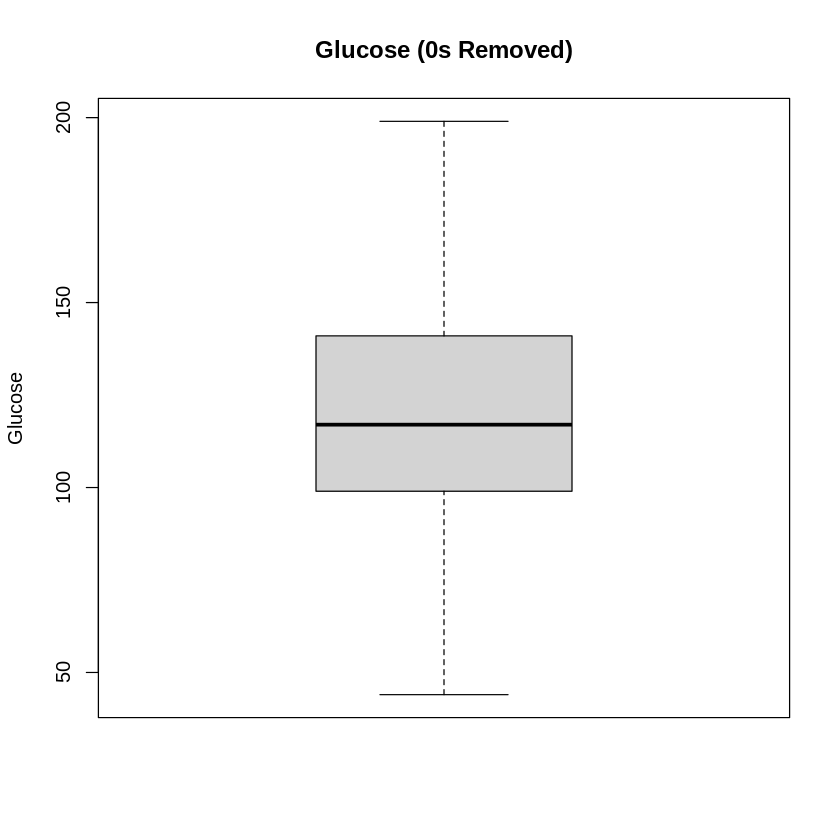

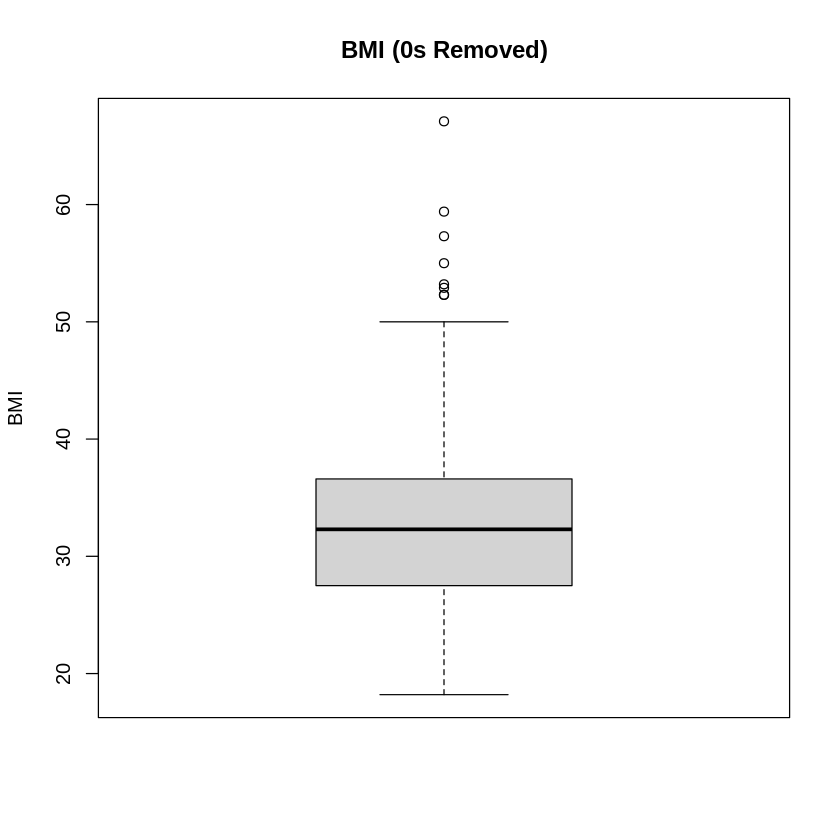

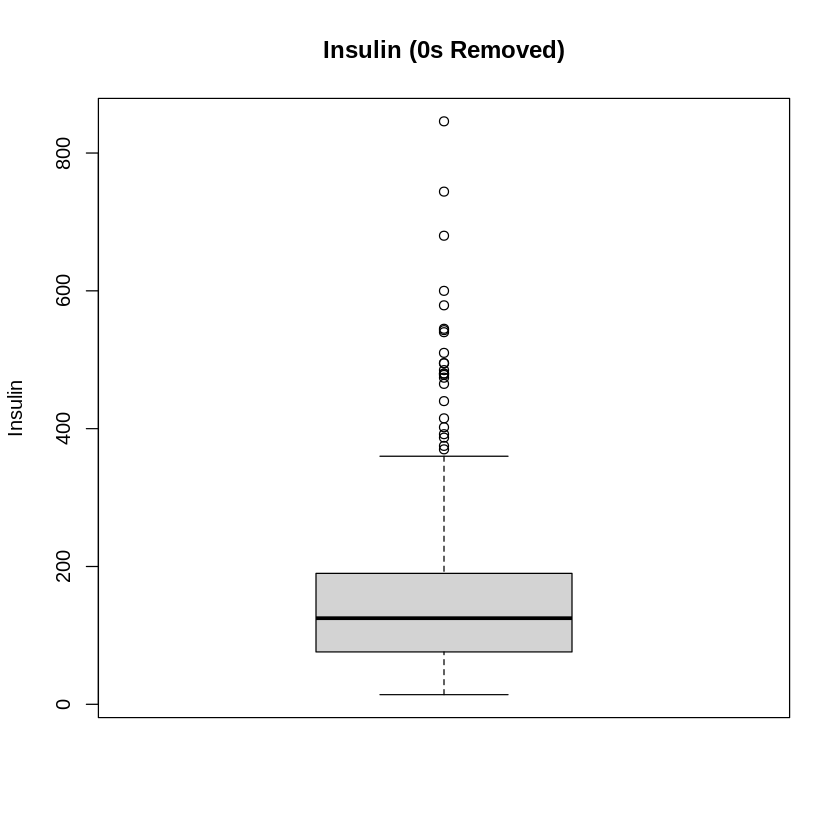

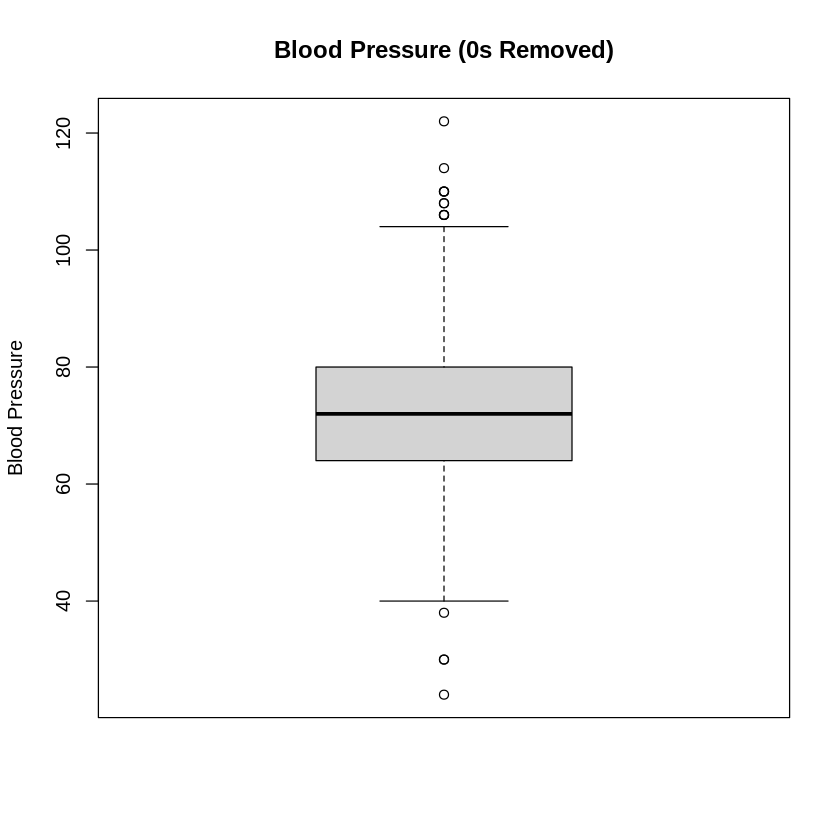

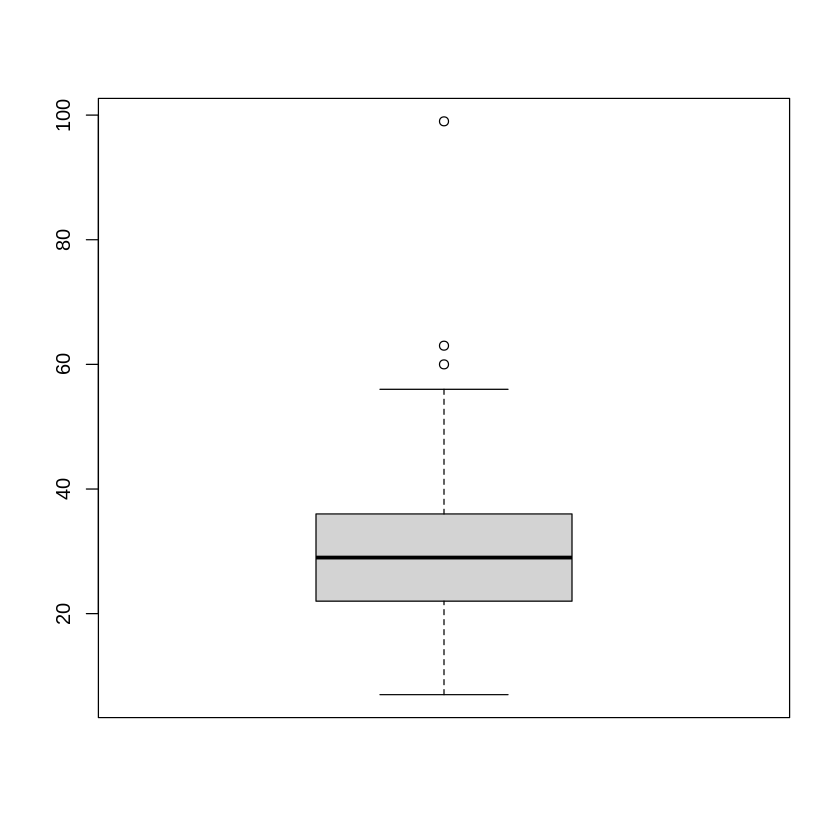

In [ ]:
glucose_no0 <- diabetes$Glucose[diabetes$Glucose != 0]
boxplot(glucose_no0, main = "Glucose (0s Removed)", ylab = "Glucose")

BMI_no0 <- diabetes$BMI[diabetes$BMI != 0]
boxplot(BMI_no0, main = "BMI (0s Removed)", ylab = "BMI")

insulin_no0 <- diabetes$Insulin[diabetes$Insulin != 0]
boxplot(insulin_no0, main = "Insulin (0s Removed)", ylab = "Insulin")

BP_no0 <- diabetes$BloodPressure[diabetes$BloodPressure != 0] # Remove 0's for Visualization
boxplot(BP_no0, main = "Blood Pressure (0s Removed)", ylab = "Blood Pressure")

SkinThickness_no0 <- diabetes$SkinThickness[diabetes$SkinThickness != 0]
boxplot(SkinThickness_no0)

     Imputed with Mean

Column Replacement

In [ ]:
# See Global Mean model

# (4.) PCA (!)

In [ ]:
# Install and Load packages
install.packages("dplyr")
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
#names(train_class)
#names(train_global)

    Class PCA

In [ ]:
#Xc_train <- train_class[, names(train_class) != "Outcome"] # (Remove Cluster)
#Xc_test <- test_class[, names(test_class) != "Outcome"]
Xc_train <- train_class[, !(names(train_class) %in% c("Outcome","Cluster"))]
Xc_test <- test_class[, !(names(test_class) %in% c("Outcome","Cluster"))]
yc_train <- train_class$Outcome
yc_test <- test_class$Outcome

pca_model_class <- prcomp(Xc_train, center = TRUE, scale. = TRUE)

pc_train_class <- predict(pca_model_class, Xc_train)
pc_test_class  <- predict(pca_model_class, Xc_test)
pc_train_class <- data.frame(Outcome = yc_train, pc_train_class[, 1:5])
pc_test_class <- data.frame(Outcome = yc_test, pc_test_class[, 1:5])


model_class_pca <- glm(Outcome ~ ., data = pc_train_class, family = binomial)

prob_class_pca <- predict(model_class_pca, newdata = pc_test_class, type = "response")
pred_class_pca <- ifelse(prob_class_pca > 0.5, 1, 0)
#mean(pred_class_pca == pc_test_class$Outcome)
#table(Predicted = pred_class_pca, Actual = pc_test_class$Outcome)

    Global PCA

In [ ]:
# Split predictors
#Xg_train <- train_global[, names(train_global) != "Outcome"] # (Remove Cluster)
#Xg_test  <- test_global[, names(test_global) != "Outcome"]
Xg_train <- train_global[, !(names(train_global) %in% c("Outcome","Cluster"))]
Xg_test  <- test_global[, !(names(test_global) %in% c("Outcome","Cluster"))]
yg_train <- train_global$Outcome
yg_test  <- test_global$Outcome

# Fit PCA (on training data ONLY)
pca_model_global <- prcomp(Xg_train, center = TRUE, scale. = TRUE)

# Transform Train and Test
pc_train_global <- predict(pca_model_global, Xg_train)
pc_test_global  <- predict(pca_model_global, Xg_test)

# Keep 1st 5 Principal Components
pc_train_global <- data.frame(Outcome = yg_train, pc_train_global[, 1:5])
pc_test_global <- data.frame(Outcome = yg_test, pc_test_global[, 1:5])

# Logisitc Regression
model_global_pca <- glm(Outcome ~ ., data = pc_train_global, family = binomial)

# Evaluate on TEST set
prob_global_pca <- predict(model_global_pca, newdata = pc_test_global, type = "response")
pred_global_pca <- ifelse(prob_global_pca > 0.5, 1, 0)

#mean(pred_global_pca == pc_test_global$Outcome)
#table(Predicted = pred_global_pca, Actual = pc_test_global$Outcome)

# Compare Models (PCA) (~)

In [ ]:
mean(pred_class_pca == pc_test_class$Outcome)
table(Predicted = pred_class_pca, Actual = pc_test_class$Outcome)
cat("\n")
mean(pred_global_pca == pc_test_global$Outcome)
table(Predicted = pred_global_pca, Actual = pc_test_global$Outcome)

[1] 0.7792208

         Actual
Predicted  0  1
        0 89 21
        1 13 31

[1] 0.7402597

         Actual
Predicted  0  1
        0 88 26
        1 14 26

In [ ]:
# PCA Summary Stats
summary(pca_model_class) # Class
cat("\n\n")
summary(pca_model_global) # Global

Importance of components:
                          PC1    PC2    PC3    PC4     PC5     PC6     PC7
Standard deviation     1.5506 1.2189 1.0539 0.9532 0.86925 0.70669 0.67831
Proportion of Variance 0.3006 0.1857 0.1388 0.1136 0.09445 0.06243 0.05751
Cumulative Proportion  0.3006 0.4863 0.6251 0.7387 0.83314 0.89557 0.95308
                           PC8
Standard deviation     0.61268
Proportion of Variance 0.04692
Cumulative Proportion  1.00000

Importance of components:
                         PC1    PC2    PC3    PC4     PC5     PC6     PC7
Standard deviation     1.515 1.2153 1.0632 0.9586 0.87289 0.73979 0.69381
Proportion of Variance 0.287 0.1846 0.1413 0.1149 0.09524 0.06841 0.06017
Cumulative Proportion  0.287 0.4717 0.6129 0.7278 0.82306 0.89147 0.95164
                           PC8
Standard deviation     0.62196
Proportion of Variance 0.04836
Cumulative Proportion  1.00000

In [ ]:
# AIC (PCA)
AIC(model_class_pca) # Class
AIC(model_global_pca) # Global

[1] 558.5366

[1] 631.5048

In [ ]:
BIC(model_class_pca)
BIC(model_global_pca)

[1] 585.0566

[1] 658.0248

In [ ]:
# Accuracy (PCA)
  # Class
prob_class_pca <- predict(model_class_pca, newdata = pc_test_class, type = "response")
pred_class_pca <- ifelse(prob_class_pca > 0.5, 1, 0)
mean(pred_class_pca == pc_test_class$Outcome)
table(Predicted = pred_class_pca, Actual = pc_test_class$Outcome)
cat("\n")
  # Global
prob_global_pca <- predict(model_global_pca, newdata = pc_test_global, type = "response")
pred_global_pca <- ifelse(prob_global_pca > 0.5, 1, 0)
mean(pred_global_pca == pc_test_global$Outcome)
table(Predicted = pred_global_pca, Actual = pc_test_global$Outcome)

[1] 0.7792208

         Actual
Predicted  0  1
        0 89 21
        1 13 31

[1] 0.7402597

         Actual
Predicted  0  1
        0 88 26
        1 14 26

# (5.) K-means Clustering (!)

    Class Mean

In [ ]:
# (Set-up)
Xc_train <- train_class[, names(train_class) != "Outcome"]
Xc_test <- test_class[, names(test_class) != "Outcome"]
Xc_train_scaled <- scale(Xc_train)
Xc_test_scaled <- scale(Xc_test, center = attr(Xc_train_scaled, "scaled:center"), scale = attr(Xc_train_scaled, "scaled:scale"))


set.seed(123)
# Fit K-means
k2_class <- kmeans(
  Xc_train_scaled, # Using Xc-scaled (Clustering does not know outcome)
  centers = 2, # Create '2' Clusters (Outcome -> 0/1)
  nstart = 25 # Run K-means 25 times, keep best solution
)
# Assign clusters
train_class$Cluster <- as.factor(k2_class$cluster)
test_class$Cluster <- as.factor(apply(Xc_test_scaled, 1, function(x) {which.min(colSums((t(k2_class$centers) - x)^2))}))

    Global Mean

In [ ]:
# (Set-up)
Xg_train <- train_global[, names(train_global) != "Outcome"]
Xg_test <- test_global[, names(test_global) != "Outcome"]
Xg_train_scaled <- scale(Xg_train)
Xg_test_scaled <- scale(Xg_test, center = attr(Xg_train_scaled, "scaled:center"), scale  = attr(Xg_train_scaled, "scaled:scale"))


set.seed(123)
# Fit K-means
k2_global <- kmeans(Xg_train_scaled, centers = 2, nstart = 25)
# Assign clusters to train + test
train_global$Cluster <- as.factor(k2_global$cluster)
test_global$Cluster <- as.factor(apply(Xg_test_scaled, 1, function(x) {which.min(colSums((t(k2_global$centers) - x)^2))}))

# K-means Diagnostics

In [ ]:
head(train_class)
table(train_class$Cluster)
table(train_class$Cluster, train_class$Outcome)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<fct>
415,0,138,60,35.00000,167.0000,34.6,0.534,21,1,2
463,8,74,70,40.00000,49.0000,35.3,0.705,39,0,2
179,5,143,78,27.27083,129.3821,45.0,0.190,47,0,1
526,3,87,60,18.00000,129.3821,21.8,0.444,21,0,2
195,8,85,55,20.00000,129.3821,24.4,0.136,42,0,2
118,5,78,48,27.27083,129.3821,33.7,0.654,25,0,2



  1   2 
268 346 

   
      0   1
  1 101 167
  2 297  49

# (6.) Logisitic Regression (using K-means) (!)

    Class

In [ ]:
model_kmeans_class <- glm(
  Outcome ~ Cluster,
  data = train_class,
  family = binomial
)

summary(model_kmeans_class)

# Predict
prob_class_km <- predict(
  model_kmeans_class,
  newdata = test_class,
  type = "response"
)

pred_class_km <- ifelse(
  prob_class_km > 0.5,
  1,
  0
)

# Accuracy
mean(pred_class_km == test_class$Outcome)
cat("\n")

# Confusion Matrix
table(
  Predicted = pred_class_km,
  Actual = test_class$Outcome
)


Call:
glm(formula = Outcome ~ Cluster, family = binomial, data = train_class)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   0.5029     0.1261   3.989 6.62e-05 ***
Cluster2     -2.3048     0.1992 -11.573  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residual deviance: 637.37  on 612  degrees of freedom
AIC: 641.37

Number of Fisher Scoring iterations: 4


[1] 0.7142857

         Actual
Predicted  0  1
        0 66  8
        1 36 44

In [ ]:
model_kmeans_class <- glm(Outcome ~ Cluster, data = train_class, family = binomial)
# Outcome ~ Glucose + BMI + Age + ...

# Evaluate
prob_class <- predict(model_kmeans_class, newdata = test_class, type = "response")
pred_class <- ifelse(prob_class > 0.5, 1, 0)
mean(pred_class == test_class$Outcome)
table(pred_class, test_class$Outcome)
  # (AIC)

[1] 0.7142857

          
pred_class  0  1
         0 66  8
         1 36 44

    Global

In [ ]:
model_kmeans_global <- glm(Outcome ~ Cluster, data = train_global, family = binomial)
# Outcome ~ Glucose + BMI + Age + ...

# Evaluate
prob_global <- predict(model_kmeans_global, newdata = test_global, type = "response")
pred_global <- ifelse(prob_global > 0.5, 1, 0)
mean(pred_global == test_global$Outcome)
table(pred_global, test_global$Outcome)
  # (AIC)

[1] 0.6948052

           
pred_global  0  1
          0 65 10
          1 37 42

In [ ]:
summary(model_kmeans_global)


Call:
glm(formula = Outcome ~ Cluster, family = binomial, data = train_global)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   0.2942     0.1237   2.378   0.0174 *  
Cluster2     -1.8001     0.1863  -9.663   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residual deviance: 693.20  on 612  degrees of freedom
AIC: 697.2

Number of Fisher Scoring iterations: 4


# LogR Using KM Results

# Diagnostics (Before Training SVM)

In [ ]:
# Diagnostics
names(train_class)
str(train_class)
table(train_class$Outcome)
dim(train_class)
  #svm_model$bestTune

[1] "Pregnancies"              "Glucose"                 
 [3] "BloodPressure"            "SkinThickness"           
 [5] "Insulin"                  "BMI"                     
 [7] "DiabetesPedigreeFunction" "Age"                     
 [9] "Outcome"                  "Cluster"

'data.frame':	614 obs. of  10 variables:
 $ Pregnancies             : int  0 8 5 3 8 5 14 4 6 1 ...
 $ Glucose                 : num  138 74 143 87 85 78 100 197 119 189 ...
 $ BloodPressure           : num  60 70 78 60 55 48 78 70 50 60 ...
 $ SkinThickness           : num  35 40 27.3 18 20 ...
 $ Insulin                 : num  167 49 129 129 129 ...
 $ BMI                     : num  34.6 35.3 45 21.8 24.4 33.7 36.6 36.7 27.1 30.1 ...
 $ DiabetesPedigreeFunction: num  0.534 0.705 0.19 0.444 0.136 ...
 $ Age                     : int  21 39 47 21 42 25 46 31 33 59 ...
 $ Outcome                 : int  1 0 0 0 0 0 1 0 1 1 ...
 $ Cluster                 : Factor w/ 2 levels "1","2": 2 2 1 2 2 2 1 1 2 1 ...



  0   1 
398 216 

[1] 614  10

# (7.) SVM (!)

In [ ]:
# Install package(s) for SVM
  # Will take a few minutes to load (10)
install.packages("e1071")
install.packages("caret")
install.packages("kernlab")
library(e1071)
library(caret)
library(kernlab)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: ggplot2


Attaching package: ‘ggplot2’


The following object is masked from ‘package:e1071’:

    element


Loading required package: lattice


Attaching package: ‘kernlab’


The following object is masked from ‘package:ggplot2’:

    alpha




    Tuned SVM

In [ ]:
train_class$Outcome <- as.factor(train_class$Outcome)
test_class$Outcome  <- as.factor(test_class$Outcome)

In [ ]:
ctrl <- trainControl(method = "cv", number = 10, classProbs = TRUE, summaryFunction = twoClassSummary)
  # cv : 10-fold cross validation

In [ ]:
train_class$Outcome <- factor(train_class$Outcome, levels = c(0, 1), labels = c("No", "Yes"))
test_class$Outcome <- factor(test_class$Outcome, levels = c(0, 1), labels = c("No", "Yes"))
  # Binary (0 & 1)

In [ ]:
grid <- expand.grid(sigma = c(0.001, 0.01, 0.05, 0.1, 0.5), C = c(0.1, 1, 5, 10, 20))
  # Tuning space (aka Test combinations)

,sigma,C
,<dbl>,<dbl>
9,0.01,10


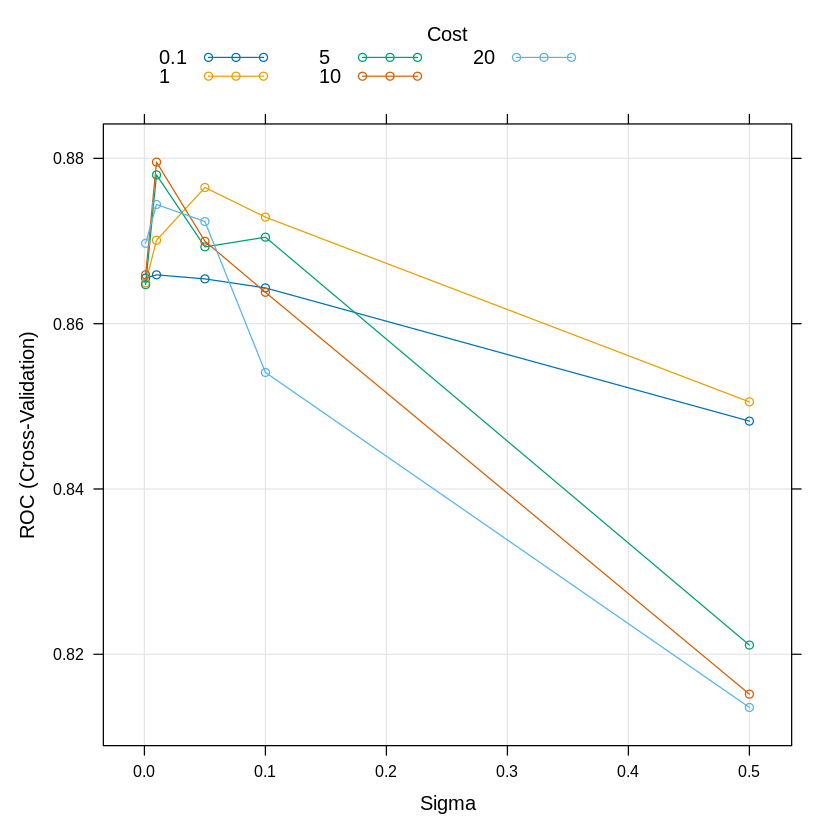

In [ ]:
# Tuned SVM
svm_model <- train(
  Outcome ~ .,
  data = train_class,
  method = "svmRadial",
  metric = "ROC",
  trControl = ctrl,
  preProcess = c("center", "scale"),
  tuneGrid = grid
)
# Inspect best model
svm_model$bestTune # The sigma and C that produced the highest ROC score
plot(svm_model)
  # X-axis: sigma or C
  # Y-axis: ROC performance

In [ ]:
# Predict on test set
pred <- predict(svm_model, newdata = test_class)
# Confusion matrix
confusionMatrix(pred, test_class$Outcome)

Confusion Matrix and Statistics

          Reference
Prediction No Yes
       No  92  12
       Yes 10  40
                                          
               Accuracy : 0.8571          
                 95% CI : (0.7917, 0.9083)
    No Information Rate : 0.6623          
    P-Value [Acc > NIR] : 3.675e-08       
                                          
                  Kappa : 0.6776          
                                          
 Mcnemar's Test P-Value : 0.8312          
                                          
            Sensitivity : 0.9020          
            Specificity : 0.7692          
         Pos Pred Value : 0.8846          
         Neg Pred Value : 0.8000          
             Prevalence : 0.6623          
         Detection Rate : 0.5974          
   Detection Prevalence : 0.6753          
      Balanced Accuracy : 0.8356          
                                          
       'Positive' Class : No              
                                 

    Original
      (-See copy file)

In [ ]:
#tune_svm <- tune(
#  svm,
#  Outcome ~ .,
#  data = train_class_scaled,
#  kernel = "radial",
#  ranges = list(
#    cost = c(0.1, 1, 10, 100),
#    gamma = c(0.01, 0.05, 0.1, 0.5, 1)
#  )
#)
#
#best_model <- tune_svm$best.model
#pred <- predict(best_model, test_class_scaled)
#
#mean(pred == test_class_scaled$Outcome)
#table(pred, test_class_scaled$Outcome)

[1] 0.8506494

    
pred  0  1
   0 92 13
   1 10 39

    Cluster Logistic Regression

In [ ]:
# “Can cluster membership alone predict diabetes?"
# Input: Cluster (0,1,2,...)
# Output: Outcome (0/1)


# Diagnostics
table(train_class$Cluster)
table(train_class$Cluster, train_class$Outcome)

# Logistic Regression
model_kmeans_class <- glm(Outcome ~ Cluster, data = train_class, family = binomial)

# Summary
summary(model_kmeans_class)


cat("\n")


# Prediction
prob_class_km <- predict(model_kmeans_class,
                         newdata = test_class,
                         type = "response")

pred_class_km <- ifelse(prob_class_km > 0.5, "Yes", "No")
pred_class_km <- factor(pred_class_km, levels = c("No", "Yes"))

# Evaluation
mean(pred_class_km == test_class$Outcome)
#table(Predicted = pred_class_km, Actual = test_class$Outcome)
AIC(model_kmeans_class)


  1   2 
268 346 

   
     No Yes
  1 101 167
  2 297  49


Call:
glm(formula = Outcome ~ Cluster, family = binomial, data = train_class)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)   0.5029     0.1261   3.989 6.62e-05 ***
Cluster2     -2.3048     0.1992 -11.573  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 796.42  on 613  degrees of freedom
Residual deviance: 637.37  on 612  degrees of freedom
AIC: 641.37

Number of Fisher Scoring iterations: 4


[1] 0.7142857

[1] 641.3651

In [ ]:
train_global$Outcome <- factor(
    train_global$Outcome,
    levels = c(0,1),
    labels = c("No","Yes")
)

test_global$Outcome <- factor(
    test_global$Outcome,
    levels = c(0,1),
    labels = c("No","Yes")
)

In [ ]:
class(train_global$Outcome)
levels(train_global$Outcome)

[1] "factor"

[1] "No"  "Yes"

    Linear Kernel

In [ ]:
# UNSCALED - Class
  # "Using ALL predictors except Cluster"


# Remove Outcome and Cluster
Xc_train_unscaled <- train_class[
    ,
    !(names(train_class) %in% c("Outcome", "Cluster"))
]

Xc_test_unscaled <- test_class[
    ,
    !(names(test_class) %in% c("Outcome", "Cluster"))
]

train_class_linear <- data.frame(
    Outcome = train_class$Outcome,
    Xc_train_unscaled
)

test_class_linear <- data.frame(
    Outcome = test_class$Outcome,
    Xc_test_unscaled
)

svm_class_linear <- svm(
    Outcome ~ .,
    data = train_class_linear,
    kernel = "linear"
)

pred_class_linear <- predict(
    svm_class_linear,
    newdata = test_class_linear
)

mean(pred_class_linear == test_class_linear$Outcome)

table(
    Predicted = pred_class_linear,
    Actual = test_class_linear$Outcome
)

[1] 0.8181818

         Actual
Predicted No Yes
      No  90  16
      Yes 12  36

In [ ]:
# UNSCALED - Global
Xg_train_unscaled <- train_global[
    ,
    !(names(train_global) %in% c("Outcome", "Cluster"))
]

Xg_test_unscaled <- test_global[
    ,
    !(names(test_global) %in% c("Outcome", "Cluster"))
]

train_global_linear <- data.frame(
    Outcome = train_global$Outcome,
    Xg_train_unscaled
)

test_global_linear <- data.frame(
    Outcome = test_global$Outcome,
    Xg_test_unscaled
)

svm_global_linear <- svm(
    Outcome ~ .,
    data = train_global_linear,
    kernel = "linear"
)

pred_global_linear <- predict(
    svm_global_linear,
    newdata = test_global_linear
)

mean(pred_global_linear == test_global_linear$Outcome)

table(
    Predicted = pred_global_linear,
    Actual = test_global_linear$Outcome
)

[1] 0.7662338

         Actual
Predicted No Yes
      No  90  24
      Yes 12  28

In [ ]:
# SCALED - Class


Xc_train_scaled <- scale(Xc_train_unscaled)

Xc_test_scaled <- scale(
    Xc_test_unscaled,
    center = attr(Xc_train_scaled, "scaled:center"),
    scale = attr(Xc_train_scaled, "scaled:scale")
)

train_class_linear_scaled <- data.frame(
    Outcome = train_class$Outcome,
    Xc_train_scaled
)

test_class_linear_scaled <- data.frame(
    Outcome = test_class$Outcome,
    Xc_test_scaled
)

svm_class_linear_scaled <- svm(
    Outcome ~ .,
    data = train_class_linear_scaled,
    kernel = "linear"
)

pred_class_linear_scaled <- predict(
    svm_class_linear_scaled,
    newdata = test_class_linear_scaled
)

mean(pred_class_linear_scaled ==
     test_class_linear_scaled$Outcome)

table(
    Predicted = pred_class_linear_scaled,
    Actual = test_class_linear_scaled$Outcome
)

[1] 0.8181818

         Actual
Predicted No Yes
      No  90  16
      Yes 12  36

In [ ]:
# SCALED - Global


Xg_train_scaled <- scale(Xg_train_unscaled)

Xg_test_scaled <- scale(
    Xg_test_unscaled,
    center = attr(Xg_train_scaled, "scaled:center"),
    scale = attr(Xg_train_scaled, "scaled:scale")
)

train_global_linear_scaled <- data.frame(
    Outcome = train_global$Outcome,
    Xg_train_scaled
)

test_global_linear_scaled <- data.frame(
    Outcome = test_global$Outcome,
    Xg_test_scaled
)

svm_global_linear_scaled <- svm(
    Outcome ~ .,
    data = train_global_linear_scaled,
    kernel = "linear"
)

pred_global_linear_scaled <- predict(
    svm_global_linear_scaled,
    newdata = test_global_linear_scaled
)

mean(pred_global_linear_scaled ==
     test_global_linear_scaled$Outcome)

table(
    Predicted = pred_global_linear_scaled,
    Actual = test_global_linear_scaled$Outcome
)

[1] 0.7662338

         Actual
Predicted No Yes
      No  90  24
      Yes 12  28

    Radial Kernel

    CLASS

In [ ]:
# UNSCALED
Xc_train_unscaled <- train_class[
    ,
    !(names(train_class) %in% c("Outcome", "Cluster"))
]
Xc_test_unscaled <- test_class[
    ,
    !(names(test_class) %in% c("Outcome", "Cluster"))
]

train_class_unscaled <- data.frame(
    Outcome = as.factor(train_class$Outcome),
    Xc_train_unscaled
)
test_class_unscaled <- data.frame(
    Outcome = as.factor(test_class$Outcome),
    Xc_test_unscaled
)

svm_class_radial <- svm(
    Outcome ~ .,
    data = train_class_unscaled,
    kernel = "radial"
)
pred_class_radial <- predict(
    svm_class_radial,
    newdata = test_class_unscaled
)


mean(pred_class_radial == test_class_unscaled$Outcome)
table(
    Predicted = pred_class_radial,
    Actual = test_class_unscaled$Outcome
)

[1] 0.8636364

         Actual
Predicted No Yes
      No  93  12
      Yes  9  40

In [ ]:
# SCALED
Xc_train_scaled <- scale(Xc_train_unscaled)
Xc_test_scaled <- scale(
    Xc_test_unscaled,
    center = attr(Xc_train_scaled, "scaled:center"),
    scale = attr(Xc_train_scaled, "scaled:scale")
)

train_class_scaled <- data.frame(
    Outcome = as.factor(train_class$Outcome),
    Xc_train_scaled
)
test_class_scaled <- data.frame(
    Outcome = as.factor(test_class$Outcome),
    Xc_test_scaled
)

svm_class_radial_scaled <- svm(
    Outcome ~ .,
    data = train_class_scaled,
    kernel = "radial"
)
pred_class_radial_scaled <- predict(
    svm_class_radial_scaled,
    newdata = test_class_scaled
)


mean(pred_class_radial_scaled ==
     test_class_scaled$Outcome)
table(
    Predicted = pred_class_radial_scaled,
    Actual = test_class_scaled$Outcome
)

[1] 0.8636364

         Actual
Predicted No Yes
      No  93  12
      Yes  9  40

    GLOBAL

In [ ]:
# UNSCALED
Xg_train_unscaled <- train_global[
    ,
    !(names(train_global) %in% c("Outcome", "Cluster"))
]
Xg_test_unscaled <- test_global[
    ,
    !(names(test_global) %in% c("Outcome", "Cluster"))
]

train_global_unscaled <- data.frame(
    Outcome = as.factor(train_global$Outcome),
    Xg_train_unscaled
)
test_global_unscaled <- data.frame(
    Outcome = as.factor(test_global$Outcome),
    Xg_test_unscaled
)

svm_global_radial <- svm(
    Outcome ~ .,
    data = train_global_unscaled,
    kernel = "radial"
)
pred_global_radial <- predict(
    svm_global_radial,
    newdata = test_global_unscaled
)


mean(pred_global_radial ==
     test_global_unscaled$Outcome)
table(
    Predicted = pred_global_radial,
    Actual = test_global_unscaled$Outcome
)

[1] 0.7662338

         Actual
Predicted No Yes
      No  90  24
      Yes 12  28

In [ ]:
# SCALED
Xg_train_scaled <- scale(Xg_train_unscaled)
Xg_test_scaled <- scale(
    Xg_test_unscaled,
    center = attr(Xg_train_scaled, "scaled:center"),
    scale = attr(Xg_train_scaled, "scaled:scale")
)

train_global_scaled <- data.frame(
    Outcome = as.factor(train_global$Outcome),
    Xg_train_scaled
)
test_global_scaled <- data.frame(
    Outcome = as.factor(test_global$Outcome),
    Xg_test_scaled
)

svm_global_radial_scaled <- svm(
    Outcome ~ .,
    data = train_global_scaled,
    kernel = "radial"
)
pred_global_radial_scaled <- predict(
    svm_global_radial_scaled,
    newdata = test_global_scaled
)


mean(pred_global_radial_scaled ==
     test_global_scaled$Outcome)
table(
    Predicted = pred_global_radial_scaled,
    Actual = test_global_scaled$Outcome
)

[1] 0.7662338

         Actual
Predicted No Yes
      No  90  24
      Yes 12  28

In [ ]:
svm_class_radial


Call:
svm(formula = Outcome ~ ., data = train_class_unscaled, kernel = "radial")


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  radial 
       cost:  1 

Number of Support Vectors:  307


# SVM Results

**Class Mean**

Accuracy
*   82.55%

Sensitivity (Recall)
*   191 / (191 + 77) = 71.3%

Specificity
*   443 / (443 + 57) = 88.6%

# (8.) KNN (!)

In [ ]:
# Install packages
install.packages("class")
library(class)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
Xc_train <- subset(train_class, select = -c(Outcome, Cluster))
Xc_test  <- subset(test_class,  select = -c(Outcome, Cluster))
Xg_train <- subset(train_global, select = -c(Outcome, Cluster))
Xg_test  <- subset(test_global,  select = -c(Outcome, Cluster))
yc_train <- train_class$Outcome
yc_test <- test_class$Outcome

Xc_train_scaled <- scale(Xc_train)
Xc_test_scaled <- scale(Xc_test, center = attr(Xc_train_scaled, "scaled:center"), scale = attr(Xc_train_scaled, "scaled:scale"))


In [ ]:
# Set-up/Prepare data
# Class Mean
  # Features/Target
Xc_train <- train_class[, names(train_class) != "Outcome"]
Xc_test <- test_class[, names(test_class) != "Outcome"]
Xc_train <- Xc_train[, names(Xc_train) != "Cluster"] # REMOVE Cluster if it exists
Xc_test <- Xc_test[, names(Xc_test) != "Cluster"] # # REMOVE Cluster if it exists
yc_train <- train_class$Outcome
yc_test <- test_class$Outcome
  # Scale
Xc_train_scaled <- scale(Xc_train)
Xc_test_scaled <- scale(Xc_test, center = attr(Xc_train_scaled, "scaled:center"), scale = attr(Xc_train_scaled, "scaled:scale"))

# Global Mean
Xg_train <- train_global[, names(train_global) != "Outcome"]
Xg_test  <- test_global[, names(test_global) != "Outcome"]
Xg_train <- Xg_train[, names(Xg_train) != "Cluster"]
Xg_test <- Xg_test[, names(Xg_test) != "Cluster"]
yg_train <- train_global$Outcome
yg_test <- test_global$Outcome
Xg_train_scaled <- scale(Xg_train)
Xg_test_scaled <- scale(Xg_test, center = attr(Xg_train_scaled, "scaled:center"), scale = attr(Xg_train_scaled, "scaled:scale"))

In [ ]:
# Tune K
k_values <- c(1,3,5,7,9,11,15)

# Class
acc_c <- sapply(k_values, function(k){
  pred <- knn(train = Xc_train_scaled, test = Xc_test_scaled, cl = yc_train, k = k)
  mean(pred == yc_test)
})

# Global
acc_g <- sapply(k_values, function(k){
  pred <- knn(train = Xg_train_scaled, test = Xg_test_scaled, cl = yg_train, k = k)
  mean(pred == yg_test)
})


results_class <- data.frame(k = k_values, accuracy = acc_c)
results_global <- data.frame(k = k_values, accuracy = acc_g)
results_class
cat("\n")
results_global

k,accuracy
<dbl>,<dbl>
1,0.8376623
3,0.8636364
5,0.8701299
7,0.8636364
9,0.8441558
11,0.8246753
15,0.8376623


k,accuracy
<dbl>,<dbl>
1,0.7402597
3,0.7727273
5,0.7792208
7,0.7857143
9,0.7857143
11,0.7792208
15,0.8051948


In [ ]:
# Pick the best K (above matrix)
  # Class : 5
  # Global : 15

# Fit Final KNN Model
knn_class_final <- knn(train = Xc_train_scaled, test = Xc_test_scaled, cl = yc_train, k = 5) # Class
knn_global_final <- knn(train = Xg_train_scaled, test = Xg_test_scaled, cl = yg_train, k = 15) # Global

# Evaluate
mean(knn_class_final == yc_test) # Class
table(Predicted = knn_class_final, Actual = yc_test)
cat("\n")
mean(knn_global_final == yg_test) # Global
table(Predicted = knn_global_final, Actual = yg_test)

[1] 0.8701299

         Actual
Predicted No Yes
      No  91   9
      Yes 11  43

[1] 0.8051948

         Actual
Predicted No Yes
      No  90  18
      Yes 12  34

# KNN Results

# Results

In [ ]:
# Create data vectors
modelCNames <- c("Logistic", "PCA + Logistic", "K-means + Logisitc", "Linear SVM (Scaled)", "Linear SVM (Unscaled)", "Radial", "KNN")
modelCAIC <- c(560.47, 558.54, 641.37, 641.37, 0, 0, 0)
modelCAccuracy <- c(78.6, 77.9, 71.4, 71.4, 80.5, 0, 87)


modelGNames <- c("Logistic", "PCA + Logistic", "K-Means + Logisitc", "Linear SVM (Scaled)", "Linear SVM (Unscaled)", "Radial SVM", "KNN (K = 15)")
modelGAIC <- c(588.24, 631.50, 697.2, 0, 0, 0, 0)
modelGAccuracy <- c(77.3, 74, 69.5, 0, 76, 0, 80.5)


# Combine into a data frame table
comparison_table_class <- data.frame(Model = modelCNames, AIC = modelCAIC, Accuracy = modelCAccuracy)
comparison_table_global <- data.frame(Model = modelGNames, AIC = modelGAIC, Accuracy = modelGAccuracy)


# Display the table in Colab
cat("Class\n")
print(comparison_table_class)
cat("\nGlobal\n")
print(comparison_table_global)

Class
                  Model    AIC Accuracy
1              Logistic 560.47     78.6
2        PCA + Logistic 558.54     77.9
3    K-means + Logisitc 641.37     71.4
4   Linear SVM (Scaled) 641.37     71.4
5 Linear SVM (Unscaled)   0.00     80.5
6                Radial   0.00      0.0
7                   KNN   0.00     87.0

Global
                  Model    AIC Accuracy
1              Logistic 588.24     77.3
2        PCA + Logistic 631.50     74.0
3    K-Means + Logisitc 697.20     69.5
4   Linear SVM (Scaled)   0.00      0.0
5 Linear SVM (Unscaled)   0.00     76.0
6            Radial SVM   0.00      0.0
7          KNN (K = 15)   0.00     80.5
